In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# 1. 데이터 로딩 및 정제
url = "https://raw.githubusercontent.com/kzming2007/Catholic_ML_final_project/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

df.columns = df.columns.str.strip()
df.rename(columns={'Temperature_T0': 'Temperature_J0'}, inplace=True)
df_clean = df.dropna().copy()

# 2. 파생 변수 생성
current_cols = [f'Current_J{i}' for i in range(6)]
speed_cols = [f'Speed_J{i}' for i in range(6)]
temp_cols = [f'Temperature_J{i}' for i in range(6)]

for i in range(6):
    df_clean[f'Power_J{i}'] = df_clean[f'Current_J{i}'] * df_clean[f'Speed_J{i}']
df_clean['Total_Power_Electric'] = (df_clean[current_cols]**2).sum(axis=1)

#input_cols = current_cols + speed_cols + ['Tool_current'] + [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric']
input_cols = current_cols + speed_cols + temp_cols + ['Tool_current'] #+ [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric']
#input_cols = current_cols + speed_cols + ['Tool_current']
#input_cols = current_cols + speed_cols
X = df_clean[input_cols]

# 3. 스케일링 (군집화 전 필수)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df_scaled = pd.DataFrame(X_scaled, columns=input_cols)

print(f"데이터 크기: {df_scaled.shape}")
print(f"사용할 피처 개수: {len(input_cols)}개")
df_scaled.head(3)

데이터 크기: (7355, 19)
사용할 피처 개수: 19개


,Current_J0,Current_J1,Current_J2,Current_J3,Current_J4,Current_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Temperature_J0,Temperature_J1,Temperature_J2,Temperature_J3,Temperature_J4,Temperature_J5,Tool_current
0,0.192630,0.341415,-0.544412,-0.763753,-0.062738,-1.188905,1.974885,-0.011159,-0.003401,-0.356207,-0.173520,-0.496422,-2.546022,-2.551400,-2.623729,-2.769168,-2.815878,-2.687978,-0.339932
1,0.778804,0.024337,0.545665,0.775323,-1.648515,-2.026353,-0.011227,-0.007389,-0.002202,0.017441,0.001111,-0.007847,-2.546022,-2.570648,-2.604856,-2.749527,-2.815878,-2.687978,5.028376
2,-0.216386,-0.627781,-1.811571,0.492934,-1.024027,0.295567,0.908961,0.156654,-3.481986,1.068067,0.032890,-1.591862,-2.546022,-2.570648,-2.604856,-2.769168,-2.798883,-2.670993,-0.381946


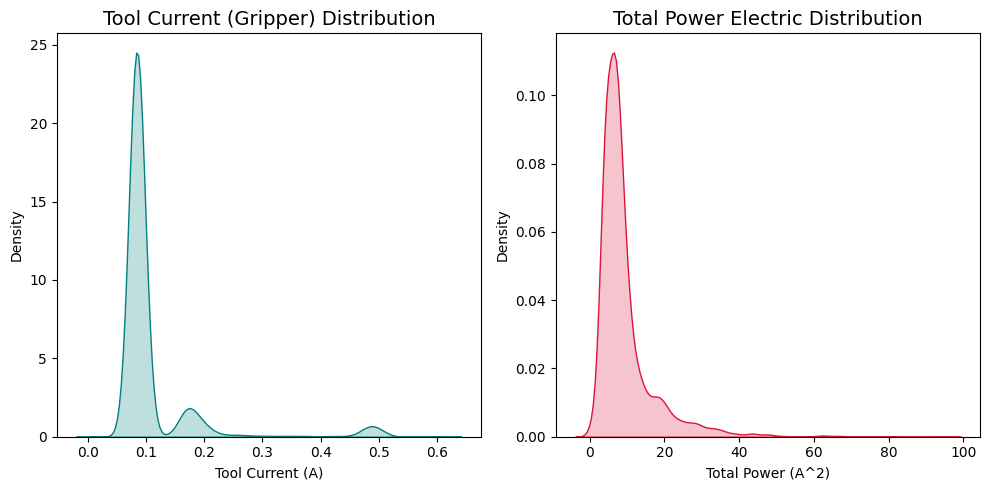


[해석 포인트]
- Tool Current 그래프에서 확연하게 3개의 봉우리(Peak)가 솟아 있다면, 
  이는 로봇이 들고 있는 3가지 무게(1kg, 2kg, 3kg)에 따라 
  그리퍼가 소모하는 전류가 3단계로 명확히 나뉘어 군집을 형성하고 있음을 시사합니다.



In [59]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 1. Tool_current 분포
sns.kdeplot(data=df_clean, x='Tool_current', fill=True, color='teal', ax=axes[0])
axes[0].set_title('Tool Current (Gripper) Distribution', fontsize=14)
axes[0].set_xlabel('Tool Current (A)')

# 2. Total Power Electric 분포
sns.kdeplot(data=df_clean, x='Total_Power_Electric', fill=True, color='crimson', ax=axes[1])
axes[1].set_title('Total Power Electric Distribution', fontsize=14)
axes[1].set_xlabel('Total Power (A^2)')


plt.tight_layout()
plt.show()

print("""
[해석 포인트]
- Tool Current 그래프에서 확연하게 3개의 봉우리(Peak)가 솟아 있다면, 
  이는 로봇이 들고 있는 3가지 무게(1kg, 2kg, 3kg)에 따라 
  그리퍼가 소모하는 전류가 3단계로 명확히 나뉘어 군집을 형성하고 있음을 시사합니다.
""")

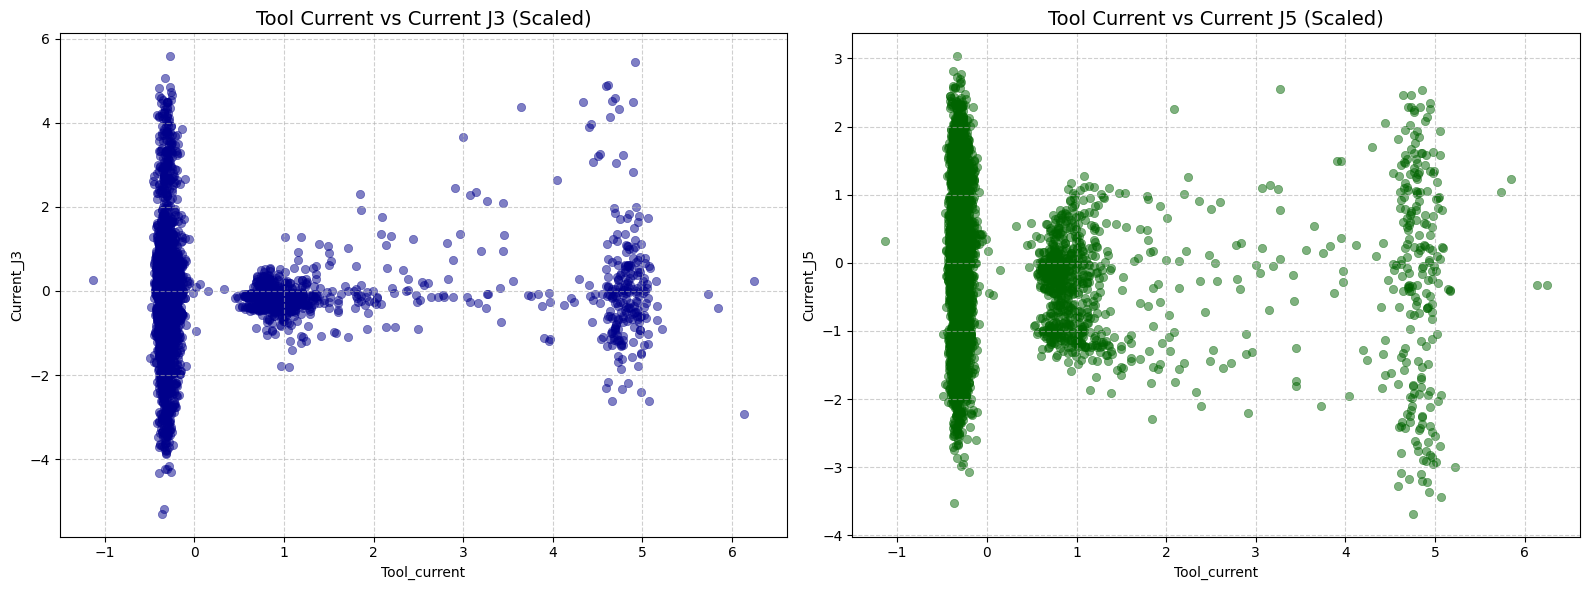


[해석 포인트]
- X축(Tool Current)을 기준으로 보았을 때 데이터가 세로로 3줄(3개의 기둥)로 쫙 갈라져 있다면 
  Tool Current가 군집화의 '마스터 키'라는 뜻입니다.
- 하지만 Y축(관절 전류) 방향으로는 데이터가 위아래로 길게 퍼져 있다면, 
  관절 전류는 하중 외에도 '로봇의 움직이는 각도/속도'에 영향을 받아 노이즈로 작용할 수 있음을 의미합니다.



In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Tool Current vs Current J3
sns.scatterplot(data=df_scaled, x='Tool_current', y='Current_J3', alpha=0.5, color='darkblue', edgecolor=None, ax=axes[0])
axes[0].set_title('Tool Current vs Current J3 (Scaled)', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Tool Current vs Current J5
sns.scatterplot(data=df_scaled, x='Tool_current', y='Current_J5', alpha=0.5, color='darkgreen', edgecolor=None, ax=axes[1])
axes[1].set_title('Tool Current vs Current J5 (Scaled)', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("""
[해석 포인트]
- X축(Tool Current)을 기준으로 보았을 때 데이터가 세로로 3줄(3개의 기둥)로 쫙 갈라져 있다면 
  Tool Current가 군집화의 '마스터 키'라는 뜻입니다.
- 하지만 Y축(관절 전류) 방향으로는 데이터가 위아래로 길게 퍼져 있다면, 
  관절 전류는 하중 외에도 '로봇의 움직이는 각도/속도'에 영향을 받아 노이즈로 작용할 수 있음을 의미합니다.
""")

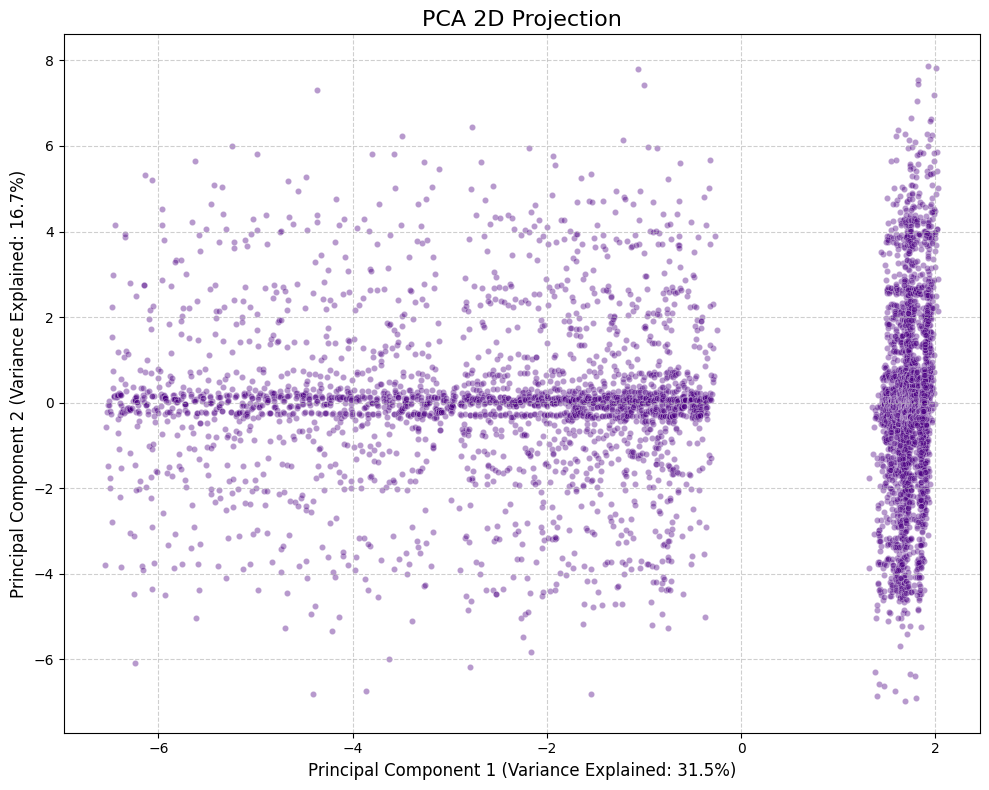


[해석 포인트]
- 점들이 거대한 하나의 덩어리로 뭉쳐있는지, 아니면 2~3개의 섬으로 떨어져 있는지 확인합니다.
- 만약 군집이 명확하게 쪼개져 있지 않고 하나로 뭉쳐 있다면, 
  단순한 K-Means로는 예쁘게 자르기 힘들 수 있으며, DBSCAN이나 계층적 군집화가 유리할 수 있습니다.
- 또한 속도/온도 등 하중과 무관한 노이즈 피처들이 섞여 있어 
  섬의 경계가 흐려졌을(차원의 저주) 가능성도 염두에 두어야 합니다.



In [3]:
# 26개 변수를 2개의 주성분으로 압축
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', alpha=0.4, color='indigo', s=20)
plt.title('PCA 2D Projection', fontsize=16)
plt.xlabel(f'Principal Component 1 (Variance Explained: {pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 (Variance Explained: {pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("""
[해석 포인트]
- 점들이 거대한 하나의 덩어리로 뭉쳐있는지, 아니면 2~3개의 섬으로 떨어져 있는지 확인합니다.
- 만약 군집이 명확하게 쪼개져 있지 않고 하나로 뭉쳐 있다면, 
  단순한 K-Means로는 예쁘게 자르기 힘들 수 있으며, DBSCAN이나 계층적 군집화가 유리할 수 있습니다.
- 또한 속도/온도 등 하중과 무관한 노이즈 피처들이 섞여 있어 
  섬의 경계가 흐려졌을(차원의 저주) 가능성도 염두에 두어야 합니다.
""")

In [3]:
df['cycle'].value_counts()

cycle
99     102
229     86
42      80
150     78
231     71
      ... 
47      23
105     23
61      22
65      22
104     11
Name: count, Length: 240, dtype: int64

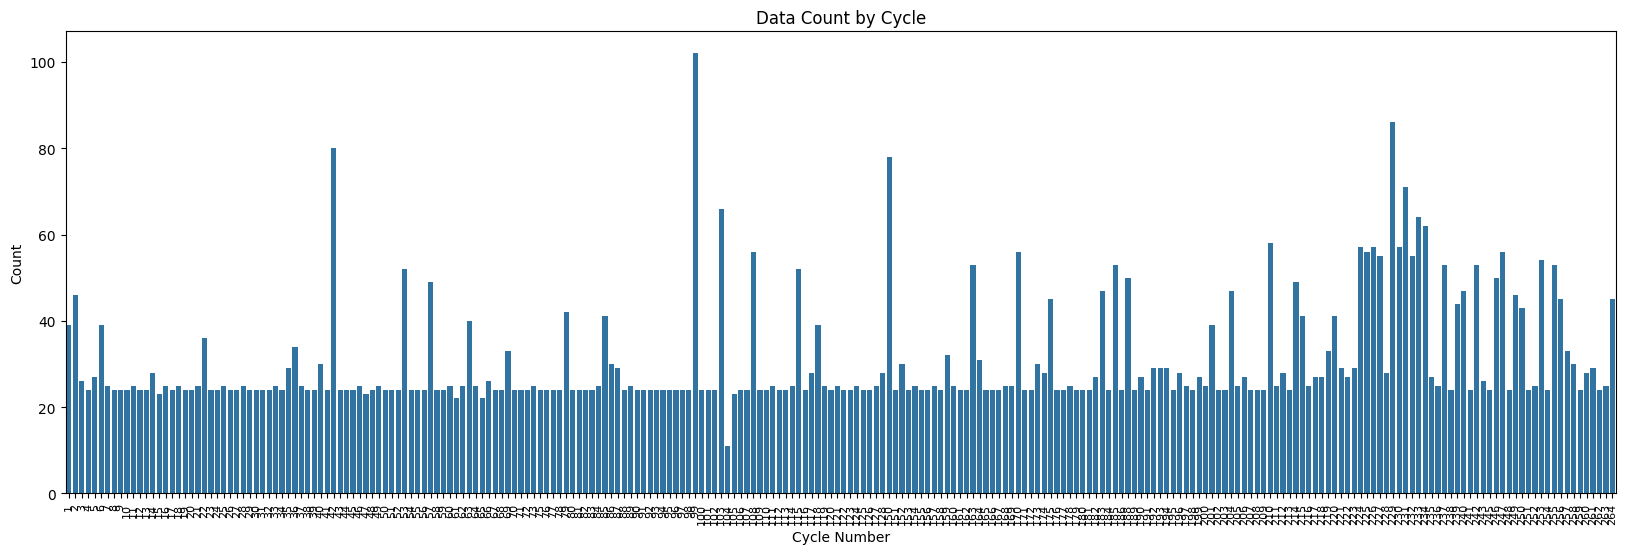

In [4]:
cycle_counts = df['cycle'].value_counts().sort_index()

plt.figure(figsize=(20, 6))
sns.barplot(x=cycle_counts.index, y=cycle_counts.values)
plt.title('Data Count by Cycle')
plt.xlabel('Cycle Number')
plt.ylabel('Count')
plt.xticks(rotation=90, fontsize=8) 
plt.show()